## Instructions
1) run every cell (top to bottom)
2) configure any of the following parameters at the sample usage

In [7]:
import numpy as np # for numerical computations and array handling
import matplotlib.pyplot as plt # 2D blackbody spectra arrays
from mpl_toolkits.mplot3d import Axes3D # for 3D plotting

In [2]:
# constants
h = 6.62607015e-34 # in joule-sec
c = 2.99792458e8 # speed of light in m/s
k = 1.380649e-23 # Boltzmann constant in joule/kelvin

In [3]:
def planck(wavelength, T):
    """
    Calculating blackbody spectral radiance using Planck's Law.

    Parameters:
    1) wavelength
    - np.array or float
    - in meters

    2) T
    - float
    - in kelvin

    when return:
    spectral rediance in W·sr^-1·m^-3

    """

    a = 2.0*h*c**2 / (wavelength**5)  # numerator = 2*h*c^2 / λ^5
    b = np.exp(h*c / (wavelength*k*T)) - 1.0 # denominator = exp(h*c / (λ*k*T)) - 1
    return a / b

In [11]:
def plot_blackbody_2d(temperatures, wavelength_range): # For 2D plot
    """
    Instruction: Plot blackbody spectra for multiple temperatures.

    Parameters:
    1) T
    - list of float
    - in kelvin

    2) wavelength_range
    - tuple
    - in meters
    
    """

    wavelengths = np.linspace(wavelength_range[0], wavelength_range[1], 500) # create 500 points linear space between start and end wavelength
    plt.figure(figsize=(10,6)) # set plot size 10x6

    for T in temperatures:
        radiance = planck(wavelengths, T) # spectral radiance for each temperature computation
        plt.plot(wavelengths*1e9, radiance, label=f'{T} K') # plot wavelength in nanometers against radiance

    plt.title("Blackbody Radiation Spectra")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Spectral Radiance W·sr⁻¹·m⁻³)")
    plt.legend() # display temp labels
    plt.grid(True)
    plt.show()

In [17]:
def plot_blackbody_3d(temperatures, wavelength_range): # for 3D plot
    """
    Plot blackbody radiation as a 3D surface: wavelength x temperature x spectral radiance

    Parameters:
    - temperatures: list of or array of temperatures in Kelvin
    - wavelength_range: tuple of start and end wavelength in meters
    """

    wavelengths = np.linspace(wavelength_range[0], wavelength_range[1], 500)
    W, T = np.meshgrid(wavelengths, temperatures)
    Z = planck(W, T)

    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(W*1e9, T, Z, cmap='plasma')

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Temperature (K)")
    ax.set_zlabel("Spectral Radiance (W·sr⁻¹·m⁻³)")
    ax.set_title("3D Blackbody Radiation Spectrum")
    

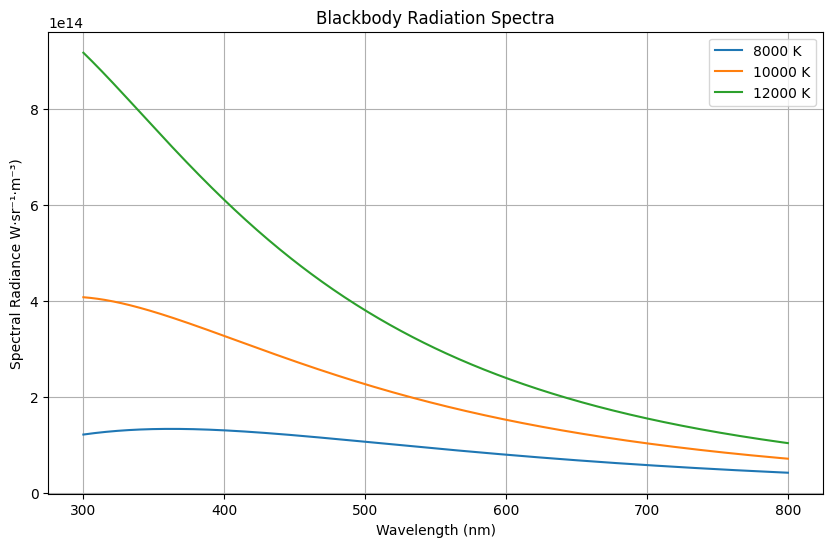

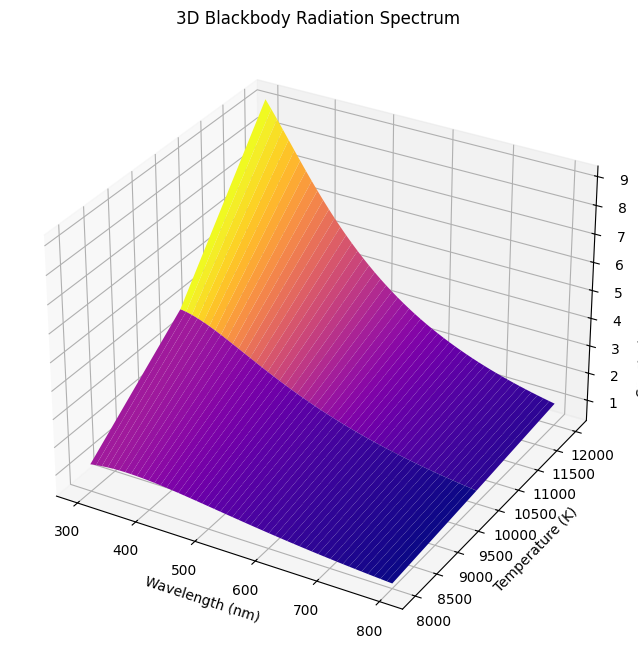

In [20]:
# EDIT / CONFIGURE PARAMETERS

# sample usage
temps = [8000, 10000, 12000] # measurements should be in kelvin
wl_range = (300e-9, 800e-9) # measurements should be in nanometers ranging within 100nm - 3000nm
plot_blackbody_2d(temps, wl_range)
plot_blackbody_3d(temps, wl_range)